In [7]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

cuda
384
tensor(0.0900, device='cuda:0', grad_fn=<MseLossBackward0>)


In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.item() * batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(self.epoch), train_loss_list, label='Train')
            ax.plot(range(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = true_energies.shape[0] / len(data)
                total_loss += batch_loss.item() * batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol 
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:26<00:00,  5.25s/it]


3.4838244531505126e-05

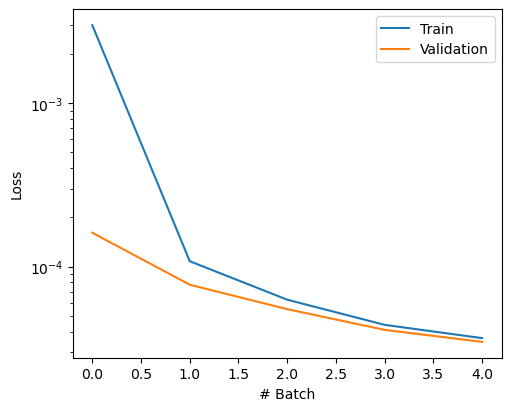

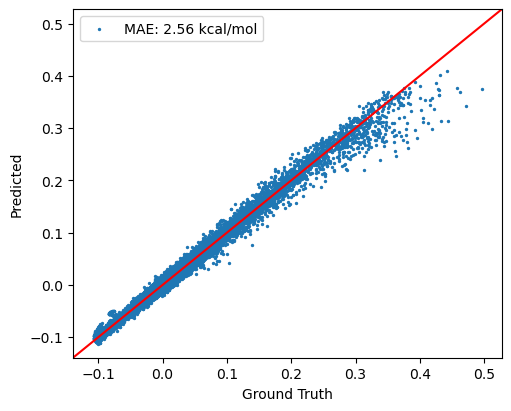

In [9]:
trainer = ANITrainer(model=model, batch_size=4096, learning_rate=1e-3, epoch=5, l2=1e-5)
train_loss, val_loss = trainer.train(train_data, val_data)
trainer.evaluate(test_data, draw_plot=True)

# Multiple Runs

In [10]:
import random, math

def build_model_seeded(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    atom_nets = [AtomicNet(), AtomicNet(), AtomicNet(), AtomicNet()]

    ani_net = torchani.ANIModel(atom_nets)
    model = nn.Sequential(aev_computer, ani_net).to(device)

    return model

def compute_mae_kcal(trainer, dataset, batch_size=4096) -> float:
    loader = dataset.collate(batch_size).cache()
    abs_sum, n = 0.0, 0
    trainer.model.eval()
    with torch.no_grad():
        for batch in loader:
            s = batch['species'].to(device)
            c = batch['coordinates'].to(device)
            t = batch['energies'].float().to(device)
            _, p = trainer.model((s, c))
            abs_sum += torch.sum(torch.abs(p - t)).item()
            n       += t.numel()
    hartree2kcal = 627.5094738898777
    return (abs_sum / n) * hartree2kcal

run_mae = []

for i in range(3):
    print(f"\n=== Run {i+1} ===")
    model_r = build_model_seeded(seed=i * 142)
    trainer_r = ANITrainer(model=model_r,
                           batch_size=4096,
                           learning_rate=1e-3,
                           epoch=5,
                           l2=1e-5)
    trainer_r.train(train_data, val_data,
                    early_stop=False, draw_curve=False)
    
    mae_kcal = compute_mae_kcal(trainer_r, test_data)
    run_mae.append(mae_kcal)
    print(f"Test MAE: {mae_kcal:.2f} kcal/mol")

print(f"\n〈Multiple-run summary〉  MAE = {np.mean(run_mae):.2f} ± {np.std(run_mae):.2f} kcal/mol")


=== Run 1 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:32<00:00,  6.56s/it]


Test MAE: 2.76 kcal/mol

=== Run 2 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:30<00:00,  6.07s/it]


Test MAE: 2.51 kcal/mol

=== Run 3 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:36<00:00,  7.35s/it]


Test MAE: 2.16 kcal/mol

〈Multiple-run summary〉  MAE = 2.47 ± 0.25 kcal/mol


# N-Fold Cross-Validation


=== Fold 1/3 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:20<00:00,  4.15s/it]


Training loss: 0.000049
Validation fold loss: 0.000043

=== Fold 2/3 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:09<00:00,  1.96s/it]


Training loss: 0.000081
Validation fold loss: 0.000073

=== Fold 3/3 ===
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 5/5 [00:26<00:00,  5.31s/it]


Training loss: 0.000040
Validation fold loss: 0.000039

=== Cross-Validation Results ===
Training Loss: 0.000056 ± 0.000018
Validation Loss: 0.000052 ± 0.000015


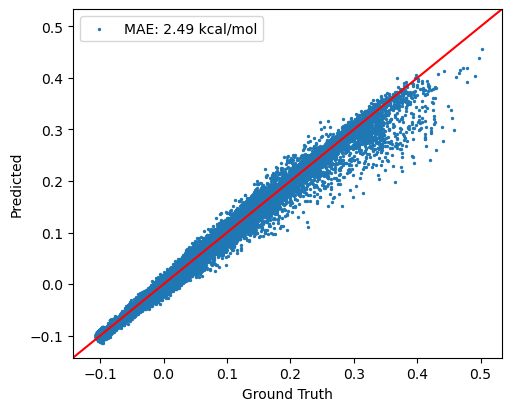

In [11]:
def ANI_KFoldCrossValidation(
    k=3,
    batch_size=4096,
    learning_rate=1e-3,
    epoch=5,
    l2=1e-5
):
    """
    Perform k-fold cross-validation on the ANI-1 dataset
    
    Args:
        k: Number of folds (3 is chosen as a balance between validation robustness and computational cost)
        batch_size: Batch size for training
        learning_rate: Learning rate for optimizer
        epoch: Number of epochs for each fold
        l2: L2 regularization parameter
        
    Returns:
        Dictionary containing train and test losses for each fold
    """
    train_loss_list = []
    val_loss_list = []
    dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
    
    fold_size = 1.0 / k
    
    for fold in range(k):
        print(f"\n=== Fold {fold+1}/{k} ===")
        
        shuffled_dataset = dataset.shuffle()
        
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size
        
        if fold == 0:
            val_fold, train_fold, _ = shuffled_dataset.split(fold_size, 1.0 - fold_size, 0.0)
        elif fold == k - 1:
            train_fold, val_fold, _ = shuffled_dataset.split(1.0 - fold_size, fold_size, 0.0)
        else:
            train1, val_fold, _ = shuffled_dataset.split(val_start, fold_size, 1.0 - val_end)
            train_fold = train1

        net_H = AtomicNet()
        net_C = AtomicNet()
        net_N = AtomicNet()
        net_O = AtomicNet()
        
        ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
        model = nn.Sequential(
            aev_computer,
            ani_net
        ).to(device)
        
        # Create a trainer
        trainer = ANITrainer(model=model, batch_size=batch_size, 
                          learning_rate=learning_rate, epoch=epoch, l2=l2)
        
        # Split train_fold into actual train and a small validation set for early stopping
        actual_train, small_val = train_fold.split(0.9, 0.1)
        
        # Train the model
        train_loss, small_val_loss = trainer.train(actual_train, small_val, draw_curve=False)
        
        # Evaluate on the validation fold (which serves as our test set for this fold)
        val_fold_loss = trainer.evaluate(val_fold, draw_plot=(fold == k-1))
        
        # Store results
        train_loss_list.append(train_loss[-1])  # Final training loss
        val_loss_list.append(val_fold_loss)    # Validation fold loss
        
        print(f"Training loss: {train_loss[-1]:.6f}")
        print(f"Validation fold loss: {val_fold_loss:.6f}")
    
    # Calculate mean and standard deviation
    mean_train_loss = np.mean(train_loss_list)
    std_train_loss = np.std(train_loss_list)
    
    mean_val_loss = np.mean(val_loss_list)
    std_val_loss = np.std(val_loss_list)
    
    # Print final results
    print("\n=== Cross-Validation Results ===")
    print(f"Training Loss: {mean_train_loss:.6f} ± {std_train_loss:.6f}")
    print(f"Validation Loss: {mean_val_loss:.6f} ± {std_val_loss:.6f}")
    
    return {
        'train_losses': train_loss_list,
        'val_losses': val_loss_list
    }

# Execute k-fold cross-validation
results_kfold = ANI_KFoldCrossValidation(k=3)

# Final Results

In [23]:
first_rec = next(iter(test_data))        # yields a Python dict
print("keys in one test record:", first_rec.keys())

keys in one test record: dict_keys(['species', 'coordinates', 'energies'])


In [24]:
num_confs = len(test_data)
mol_idx   = np.zeros(num_confs, dtype=int)

HARTREE2KCAL = 627.5094738898777

def energy_metrics_kcal(trainer, dataset, per_mol_idx, cap_kcal=None):
    # collect predictions
    ref, pred = [], []
    loader = dataset.collate(4096).cache()
    trainer.model.eval()
    with torch.no_grad():
        for b in loader:
            s = b['species'].to(device)
            c = b['coordinates'].to(device)
            t = b['energies'].float().to(device)
            _, p = trainer.model((s, c))
            ref.append(t.cpu().numpy()); pred.append(p.cpu().numpy())
    ref = np.concatenate(ref)*HARTREE2KCAL
    pred= np.concatenate(pred)*HARTREE2KCAL

    total_rmse = np.sqrt(np.mean((pred-ref)**2))
    total_mae  = np.mean(np.abs(pred-ref))

    # --- relative energies (per molecule) ------------------------
    ref_min   = np.bincount(per_mol_idx, ref,  per_mol_idx.max()+1)[per_mol_idx]
    ref_rel   = ref  - ref_min
    pred_rel  = pred - ref_min
    rel_err   = pred_rel - ref_rel
    if cap_kcal is not None:           # apply 30-kcal window if requested
        mask = np.abs(ref_rel) <= cap_kcal
        rel_err = rel_err[mask]
    rel_rmse = np.sqrt(np.mean(rel_err**2))

    return total_mae, total_rmse, rel_rmse

mae_tot, rmse_tot, rmse_rel30 = energy_metrics_kcal(trainer, test_data, mol_idx, cap_kcal=30)
rmse_rel_inf                  = energy_metrics_kcal(trainer, test_data, mol_idx, cap_kcal=None)[2]

print(f"total RMSE  : {rmse_tot:.2f} kcal/mol")
print(f"total MAE   : {mae_tot :.2f} kcal/mol")
print(f"rel RMSE ≤30 kcal : {rmse_rel30:.2f} kcal/mol")
print(f"rel RMSE full span: {rmse_rel_inf:.2f} kcal/mol")

/global/scratch/users/ericwangyz/chem242/ani/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/scratch/users/ericwangyz/chem242/ani/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


total RMSE  : 3.70 kcal/mol
total MAE   : 2.56 kcal/mol
rel RMSE ≤30 kcal : nan kcal/mol
rel RMSE full span: 104892.32 kcal/mol


In [25]:
paper_numbers = {
    "total RMSE"          : 1.3,   # kcal mol-1, text §4
    "rel RMSE ≤30 kcal"   : 0.6,   # Fig 4A
    "rel RMSE full span"  : 1.8,   # Fig 4A
}

ours = {
    "total RMSE"          : round(rmse_tot,  2),
    "rel RMSE ≤30 kcal"   : round(rmse_rel30,2),
    "rel RMSE full span"  : round(rmse_rel_inf,2),
}

df = pd.DataFrame([ours, paper_numbers], index=["this work", "ANI-1 paper"]).T
df.style.set_caption("Table 1  Comparison of key metrics on ANI-1 GDB-S01–S04 (kcal/mol)")

,this work,ANI-1 paper
total RMSE,3.700000,1.300000
rel RMSE ≤30 kcal,nan,0.600000
rel RMSE full span,104892.320000,1.800000
